In [101]:
%pylab inline 
from scipy.signal import convolve2d


Populating the interactive namespace from numpy and matplotlib


In [118]:
def compute_focus(r=int(N/20),_plt=False):
    C=np.zeros([2*r,2*r])

    for i in range(2*r):
        for j in range(2*r):
            if sqrt((i-r)**2+(j-r)**2)<r-1:
                C[i,j]=1
    C=C/sum(C.flatten())
    if _plt:
        figure()
        imshow(C);
        title('Convolution kernel')


    #conditional expectation
    Conv=convolve2d(P,C,mode='same')
    if _plt:
        figure()
        imshow(Conv)
        title('Conditional expectation for balls')

    #centers of balls with significant conditional expectation
    Conv[Conv>gamma2]=1
    Conv[Conv<-gamma2]=-1
    Conv[abs(Conv)<gamma2]=0
    if _plt:
        figure()
        imshow(Conv)
        title('Conditional expectation is outside -gamma,gamma')

    Pos=copy(Conv) #centers of balls with significant positive expectation
    Pos[Pos<0]=0
    Neg=copy(Conv) #centers of balls with significant negative expectation
    Neg[Neg>0]=0
    if _plt:
        figure()
        imshow(Pos)
        title('significant positive')
        figure()
        imshow(Neg)
        title('significant negative')

    # Conv_Pos is positive if there is a significant positive ball overlapping it
    Conv_Pos=convolve2d(Pos,C,mode='same')
    if _plt:
        figure()
        imshow(Conv_Pos)
        title('positive evidence')
    
    # Conv_neg is negative if there is a significant negative ball overlapping it
    Conv_Neg=convolve2d(Neg,C,mode='same')
    if _plt:
        figure()
        imshow(Conv_Neg)
        title('negative evidence')

    #Disagreement points "!"
    disagree=(Conv_Pos>0)*(Conv_Neg<0)

    if _plt:
        figure()
        imshow(disagree)
        title('disagreement points "!"')

    disagree_conv=convolve2d(disagree,C,mode='same')
    focus_set=disagree_conv>0
    if _plt:
        figure()
        imshow(focus_set);
        title('focus set')
    return focus_set

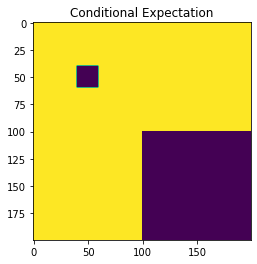

In [124]:
N=200
r=5
gamma1=0.3 #creation
gamma2=0.2 #analysis

P=ones([N,N])*gamma1

frac=int(N/2)
P[frac:,frac:]*=-1

step=int(N/10)
P[2*step:3*step,2*step:3*step]*=-1
imshow(P);
title('Conditional Expectation');


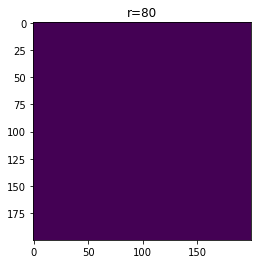

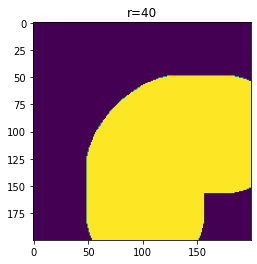

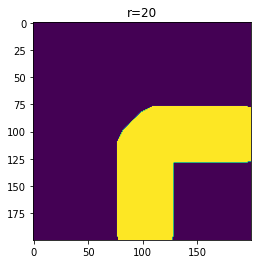

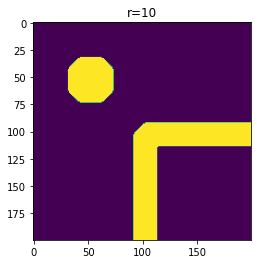

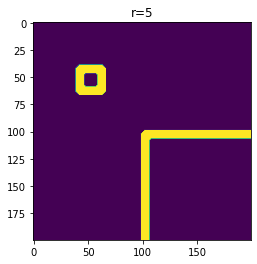

In [128]:
focus={}
for _r in [80,40,20,10,5]:
    focus[_r]=compute_focus(r=_r)
    figure()
    imshow(focus[_r])
    title(f'r={_r}')
                            
                            

In [122]:
int(N/5)

20

In [129]:
f=zeros([N,N])

In [130]:
i=1
for k in focus:
    f[focus[k]!=0]=i
    i+=1

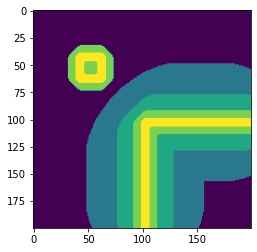

In [135]:
imshow(f);

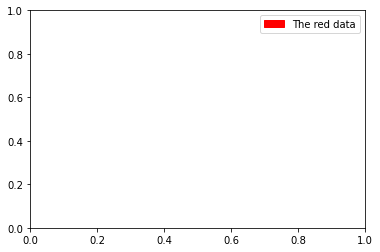

In [133]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
red_patch = mpatches.Patch(color='red', label='The red data')
ax.legend(handles=[red_patch])

plt.show()